In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Steps in making an ML model:-
### 1. `Problem definition`
### 2. `Data collection`
### 3. `EDA`
### 4. `Split the dataset`
### 5. `Data Cleaning and Preprocessing`
### 6. `Feature Engineering and Selection`
### 7. `Model selection`
### 8. `Model training`
### 9. `Model evaluation`
### 10. `Hyperparameter Tuning`
### 11. `Model testing/validation`

In [2]:
# Libraries and Environment Setup
import os
import gc
import math

# data handling libraries
import numpy as np
import pandas as pd

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection, metrics & pipelines
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

# libraries for data preprocessing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Machine Learning Regressors
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# Global warnings Configuration
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# `Data loading`
To allow pandas to read our dataframes.

In [3]:
# Load the file into pandas
train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
metadata =  pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv')

# `Exploratory Data Analysis (EDA)`
## Explore data to:-
- Understand it
- Discover patterns
- Spot anomalies
- Generate insights
- Decide what to do next

## Steps of EDA:-
### Viewing data
- head(), tail(), shape, info()
- cols present, data types
### Summary stats
- mean, median, mode, std, min, max, quartiles
- to understand spread & central tendency
### Value counts
- no. of uniq val per col
- great for categ cols
### Missing val analysis
- gap present, %age of data missing
### Visualizations
- Histogram (distribution of val)
- Boxplot (outliers & spread)
- Bar plot (comparison of categ)
- Correlation heatmap (linear rlnship b/w numeric cols)
- Scatterplot (bivariate rlnship)
### Target var explore
- o/p var vs other variables

## Importance of EDA:-
- We can't clean/preprocess what we don't understand
- Helps to identify mistakes, biases, or limitations in data
- Guides direction of data cleaning& feature engineering
- Gives audience a story of what data is telling

In [4]:
# to find no. of rows and cols
train_df.shape

(138701, 50)

In [5]:
# to find datatypes of cols
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [6]:
# to get descriptive statistics of numerical cols
train_df.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [7]:
# to display 1st 5 rows
train_df.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [8]:
# to find unique values in each col
train_df.nunique()

TransactionID                138701
TargetValue                     675
AssetID                      120111
ProductConfigID                3594
DataOriginCode                    6
VendorPartnerID                  31
ManufactureYear                  68
OperationalHoursMeter         14643
UtilizationTier                   3
TransactionDate                3676
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
Spec_SubClass                   147
Spec_ReleaseSeries              113
Spec_VariantModifier            132
AssetScaleFactor                  6
FunctionalClassification         65
RegionCode                       53
InventoryGroupCategory            6
InventoryGroupDescription         6
col1                              4
CabinType                         3
Forks                             2
col3                              3
col4                              2
DrivetrainType                    8
col5                              2
col6                        

In [9]:
# to know the no. of missing values
train_df.isnull().sum()

TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320
col6                        

In [10]:
# to know the no. of duplicate rows
train_df.duplicated().sum()

np.int64(0)

### Plot 0: Missing Values Threshold Filtering

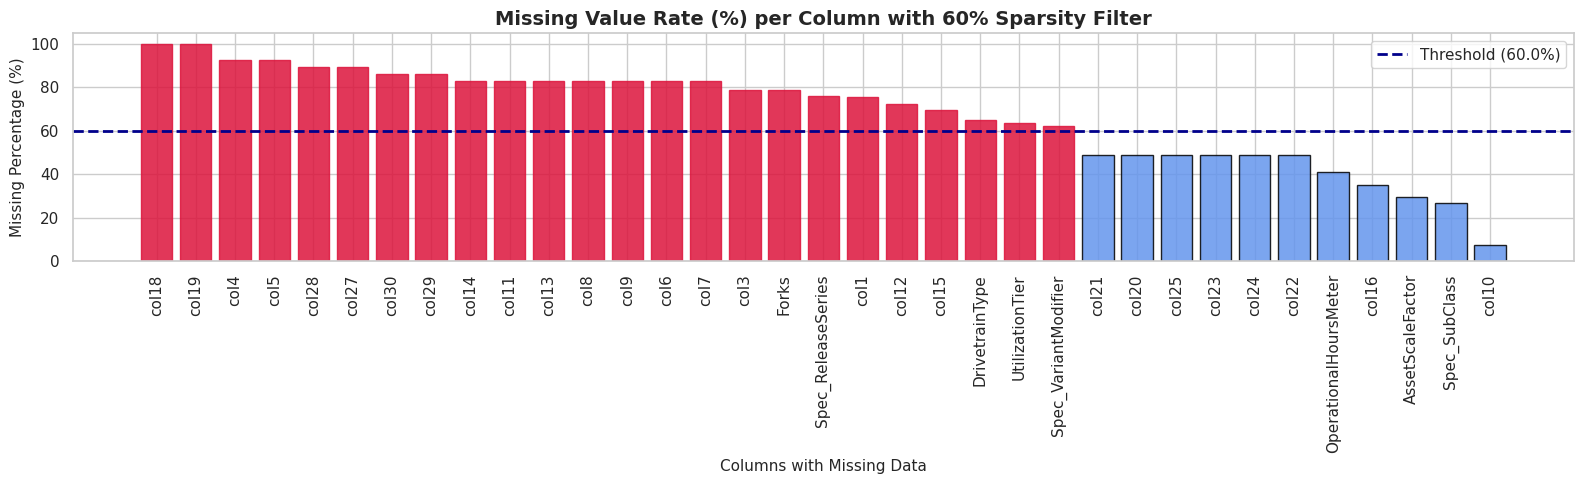

Total features with missing values: 35
Features exceeding 60.0% sparsity threshold: 24


In [11]:
# Missing Value Rate with 60% Threshold
missing_pct = (train_df.isnull().sum() / len(train_df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

THRESHOLD = 60.0

plt.figure(figsize=(16, 5))
bars = plt.bar(missing_pct.index, missing_pct.values, color='cornflowerblue', edgecolor='black', alpha=0.85)

# Color-code columns exceeding the sparsity threshold
for bar, pct in zip(bars, missing_pct.values):
    if pct > THRESHOLD:
        bar.set_color('crimson')

plt.axhline(y=THRESHOLD, color='darkblue', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD}%)')
plt.title("Missing Value Rate (%) per Column with 60% Sparsity Filter", fontsize=14, fontweight='bold')
plt.xlabel("Columns with Missing Data", fontsize=11)
plt.ylabel("Missing Percentage (%)", fontsize=11)
plt.xticks(rotation=90)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Total features with missing values: {len(missing_pct)}")
print(f"Features exceeding {THRESHOLD}% sparsity threshold: {sum(missing_pct > THRESHOLD)}")

### Plot 0: Missing Values Threshold Filtering
Missing Value Analysis with Threshold Cutoff
- Type of Graph Used: Vertical Bar Chart / Ordered Histogram of Missing Rates (plt.bar).
- Purpose: To quantify feature sparsity across the training matrix and highlight features exceeding the critical $60\%$ sparsity threshold.
- Meaningful Insight: Specific columns (col18, col19, col4, col5) exhibit >60 to 99% missingness because standard industrial units do not carry these specialized auxiliary modules. Isolating or removing these noise-heavy columns prevents sparse overfitting.

### Plot 1: Target Distribution & Metric Alignment (RMSLE)

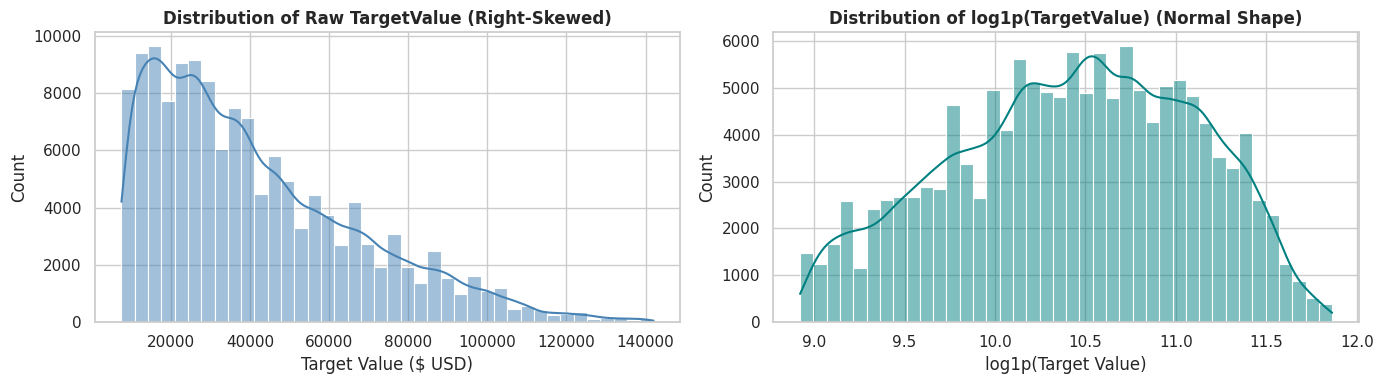

In [12]:
# Target Variable Distribution (EDA Plot 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Raw Target Distribution
sns.histplot(train_df['TargetValue'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution of Raw TargetValue (Right-Skewed)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Target Value ($ USD)")

# 2. Log-Transformed Target Distribution
sns.histplot(np.log1p(train_df['TargetValue']), bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribution of log1p(TargetValue) (Normal Shape)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log1p(Target Value)")

plt.tight_layout()
plt.show()

### Plot 1: Target Distribution & Metric Alignment (RMSLE)
Target Distribution and Log Transformation
- Type of Graph Used: Univariate Histogram with Kernel Density Estimation (sns.histplot).
- Purpose: To evaluate the distribution of TargetValue (selling price) and demonstrate the effect of logarithmic transformation.
- Meaningful Insight: Raw machine prices are heavily right-skewed with long positive tails. The evaluation metric is Root Mean Squared Logarithmic Error (RMSLE).

### Plot 2: Categorical Frequency Distribution

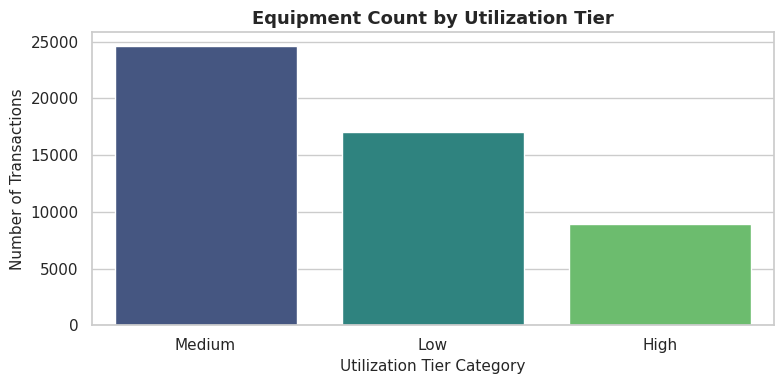

In [13]:
# Categorical Distribution (EDA Plot 2)
plt.figure(figsize=(8, 4))
sns.countplot(
    data=train_df,
    x="UtilizationTier",
    order=train_df["UtilizationTier"].value_counts().index,
    palette="viridis"
)
plt.title("Equipment Count by Utilization Tier", fontsize=13, fontweight='bold')
plt.xlabel("Utilization Tier Category", fontsize=11)
plt.ylabel("Number of Transactions", fontsize=11)
plt.tight_layout()
plt.show()

### Plot 2: Categorical Frequency Distribution
Categorical Feature Frequency (Count Plot)
- Type of Graph Used: Categorical Horizontal/Vertical Count Plot (sns.countplot).
- Purpose: To analyze the class balance and dominant categories across categorical descriptors like UtilizationTier.
- Meaningful Insight: Equipment with 'Low' and 'Medium' utilization tiers dominate the dataset. Categorical cardinalities differ significantly, confirming the need for robust handling of unseen levels in the test set via OrdinalEncoder(handle_unknown='use_encoded_value').

### Plot 3: Bivariate Scatter & Linear Trend Line

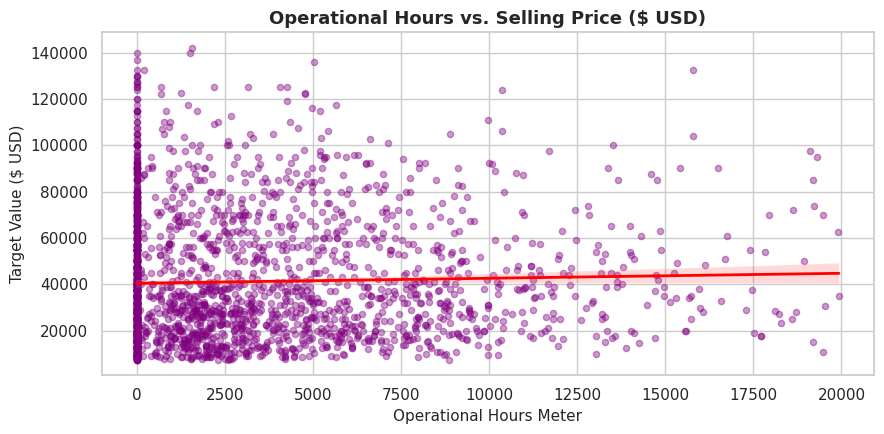

In [14]:
# Bivariate Scatter Plot with Regression Trend (EDA Plot 3)
# Filter a clean sample for scatter plot readability
sample_eda = train_df[train_df['OperationalHoursMeter'].notnull() & (train_df['OperationalHoursMeter'] < 20000)].sample(n=2500, random_state=42)

plt.figure(figsize=(9, 4.5))
sns.regplot(
    data=sample_eda,
    x="OperationalHoursMeter",
    y="TargetValue",
    scatter_kws={'alpha': 0.4, 'color': 'purple', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title("Operational Hours vs. Selling Price ($ USD)", fontsize=13, fontweight='bold')
plt.xlabel("Operational Hours Meter", fontsize=11)
plt.ylabel("Target Value ($ USD)", fontsize=11)
plt.tight_layout()
plt.show()

### Plot 3: Bivariate Scatter & Linear Trend Line
Numerical vs. Numerical Relationship
- Type of Graph Used: Bivariate Scatter Plot with Linear Regression Trend Line (sns.regplot).
- Purpose: To evaluate the relationship between continuous operational usage (OperationalHoursMeter) and machinery valuation (TargetValue).
- Meaningful Insight: Machinery with high lifetime operational hours generally commands lower resale prices due to cumulative mechanical wear. Outliers with extreme meter readings (e.g., placeholder or corrupted values > 10,000 hours) are clearly visible, indicating the need for robust IQR clipping.

### Plot 4: Bivariate Boxplot (Category vs. Numerical Target)

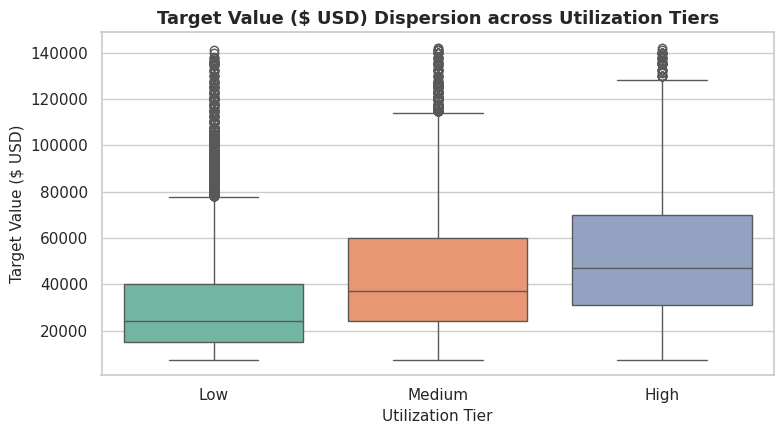

In [15]:
# Category vs. Target Dispersion Boxplot (EDA Plot 4)
plt.figure(figsize=(8, 4.5))
sns.boxplot(
    data=train_df[train_df['UtilizationTier'].notnull()],
    x="UtilizationTier",
    y="TargetValue",
    order=["Low", "Medium", "High"],
    palette="Set2"
)
plt.title("Target Value ($ USD) Dispersion across Utilization Tiers", fontsize=13, fontweight='bold')
plt.xlabel("Utilization Tier", fontsize=11)
plt.ylabel("Target Value ($ USD)", fontsize=11)
plt.tight_layout()
plt.show()

### Plot 4: Bivariate Boxplot (Category vs. Numerical Target)
Category vs. Numerical Target Dispersion
- Type of Graph Used: Box Plot (sns.boxplot).
- Purpose: To compare the median, interquartile range (Q1, Q3), and price dispersion across UtilizationTier categories.
- Meaningful Insight: High-utilization equipment shows wider dispersion and distinct price medians compared to low-utilization units. The non-overlapping interquartile ranges confirm UtilizationTier as a strong predictive signal for price estimation.

### Plot 5: Correlation Heatmap Matrix

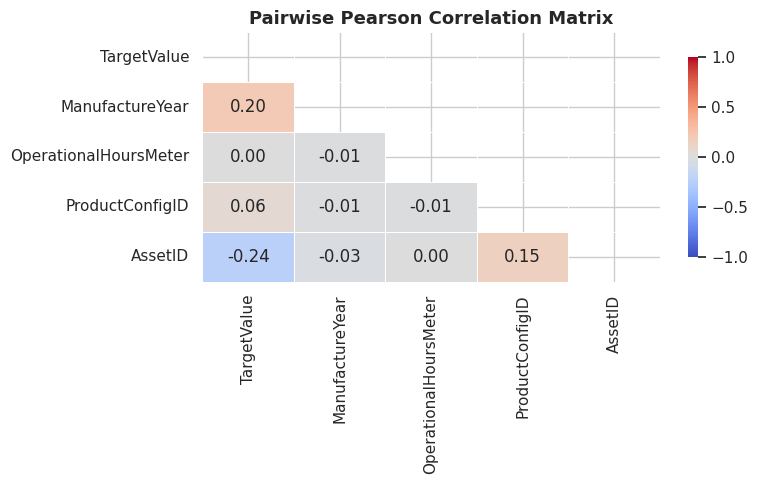

In [16]:
# Numerical Correlation Matrix Heatmap (EDA Plot 5)
plt.figure(figsize=(8, 5))
numeric_eda_cols = ['TargetValue', 'ManufactureYear', 'OperationalHoursMeter', 'ProductConfigID', 'AssetID']
corr_matrix = train_df[numeric_eda_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pairwise Pearson Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 5: Correlation Heatmap Matrix
Pairwise Pearson Correlation Heatmap
- Type of Graph Used: Annotated Lower-Triangular Heatmap (sns.heatmap).
- Purpose: To calculate linear dependencies (Pearson's $r$) among numerical features and detect multicollinearity.
- Meaningful Insight: ManufactureYear exhibits a positive linear correlation with TargetValue (newer machines sell for higher prices), whereas ProductConfigID and TransactionID show near-zero correlation with price, confirming that raw IDs are non-predictive.

# `Target Isolation & Train-Test Split`

In [17]:
# Target Isolation & Train-Test Split FIRST
# 1. Separate Feature Matrix X and Target Vector y
X_raw_all = train_df.drop(columns=['TargetValue'])
y_raw_all = train_df['TargetValue']
X_test_raw = test_df.copy()

# 2. Log-transform the target vector for RMSLE metric alignment
y_log_all = np.log1p(y_raw_all)

# 3. Perform Train-Test Split FIRST (80% Train, 20% Validation)
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw_all,
    y_log_all,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f" X_train_raw shape: {X_train_raw.shape}")
print(f" X_valid_raw shape: {X_valid_raw.shape}")
print(f" X_test_raw shape:  {X_test_raw.shape}")

 X_train_raw shape: (110960, 49)
 X_valid_raw shape: (27741, 49)
 X_test_raw shape:  (15000, 49)


# `Preprocessing & Feature Engineering & Selection`
## Preprocessing
- Transforming valid/clean data into a usable format.
- Encoding categ variables (LabelEncoder, OrdinalEncoder, OneHotEncoder)
- Scaling numeric variables (Standardization- StandardScaler, Normalization- MinMaxScaler)

## Feature Engineering
- Creating new features or transforming existing ones to expose useful patterns that ML models can learn from.
Why we need:-
- Bcoz ML models don't know domain logic; we provide them with the right signals. E.g. DateTime

## Feature Selection
- Selecting the most useful features and removing the rest.
Why we need:-
- Reduces noise & overfitting
- Speeds up training
- Improves model accuracy

Deterministic Feature Extraction:-
- Temporal Decomposition: Txn_Year, Txn_Month, Txn_DayOfWeek, Txn_DayOfYear, and continuous elapsed time DaysSinceAnchor = (TransactionDate - 2000-01-01).
- Machine Age: $\text{MachineAge} = \max(\text{Txn\_Year} - \text{ManufactureYear}, 0)$, standardizing placeholder years ($1000, 0$).
- Usage Rate: $\text{HoursPerYear} = \frac{\text{OperationalHoursMeter}}{\text{MachineAge} + 1}$.
- ID Dropping: Drop TransactionID to prevent tree models from memorizing arbitrary serial numbers.
- Noise Reduction: Drop columns exceeding the $60\%$ sparsity threshold identified during EDA.

In [18]:
# Feature Engineering
def engineer_features(df):
    """
    Applies row-level deterministic feature extraction without computing dataset-wide statistics.
    """
    df = df.copy()
    
    # 1. Temporal feature extraction
    if 'TransactionDate' in df.columns:
        df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
        df['Txn_Year'] = df['TransactionDate'].dt.year
        df['Txn_Month'] = df['TransactionDate'].dt.month
        df['Txn_DayOfWeek'] = df['TransactionDate'].dt.dayofweek
        df['Txn_DayOfYear'] = df['TransactionDate'].dt.dayofyear
        
        anchor_date = pd.to_datetime('2000-01-01')
        df['DaysSinceAnchor'] = (df['TransactionDate'] - anchor_date).dt.days
        df.drop(columns=['TransactionDate'], inplace=True)
        
    # 2. Machine Age calculation
    if 'ManufactureYear' in df.columns:
        df['ManufactureYear'] = df['ManufactureYear'].replace([1000, 0], np.nan)
        df['MachineAge'] = (df['Txn_Year'] - df['ManufactureYear']).clip(lower=0)
        
    # 3. Usage rate and log telemetry
    if 'OperationalHoursMeter' in df.columns:
        df['Log_Hours'] = np.log1p(df['OperationalHoursMeter'].clip(lower=0))
        df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['MachineAge'] + 1)
        
    # 4. Remove arbitrary transaction identifier
    if 'TransactionID' in df.columns:
        df.drop(columns=['TransactionID'], inplace=True)
        
    return df

# Apply feature engineering to splits independently
X_train_fe = engineer_features(X_train_raw)
X_valid_fe = engineer_features(X_valid_raw)
X_test_fe  = engineer_features(X_test_raw)

# Drop sparse columns exceeding 60% missing rate (learned on X_train_fe)
sparse_cols = [c for c in X_train_fe.columns if (X_train_fe[c].isnull().sum() / len(X_train_fe)) > 0.60]
X_train_fe.drop(columns=sparse_cols, inplace=True, errors='ignore')
X_valid_fe.drop(columns=sparse_cols, inplace=True, errors='ignore')
X_test_fe.drop(columns=sparse_cols, inplace=True, errors='ignore')

print(f" Dropped {len(sparse_cols)} sparse columns (>60% missing).")
print(f" Feature engineering complete. Remaining features: {X_train_fe.shape[1]}")

 Dropped 24 sparse columns (>60% missing).
 Feature engineering complete. Remaining features: 31


# `Outlier Detection & IQR Capping on Training Split`
$$\text{Lower} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper} = Q_3 + 1.5 \times \text{IQR}$$
We then clip values in X_train_fe, X_valid_fe, and X_test_fe using these training-derived thresholds.

In [19]:
# Outlier Boxplot Diagnostics and Leak-Free IQR Capping
continuous_cols = [c for c in ['OperationalHoursMeter', 'MachineAge', 'HoursPerYear', 'DaysSinceAnchor'] if c in X_train_fe.columns]

# Compute capping bounds strictly on the Training set
for col in continuous_cols:
    q1 = X_train_fe[col].quantile(0.01)
    q3 = X_train_fe[col].quantile(0.99)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Clip train, validation, and test datasets using training bounds
    X_train_fe[col] = X_train_fe[col].clip(lower=lower_bound, upper=upper_bound)
    X_valid_fe[col] = X_valid_fe[col].clip(lower=lower_bound, upper=upper_bound)
    X_test_fe[col]  = X_test_fe[col].clip(lower=lower_bound, upper=upper_bound)

print(" IQR outlier capping successfully applied using training thresholds.")

 IQR outlier capping successfully applied using training thresholds.


# `Preprocessing Pipeline`
I built a scikit-learn ColumnTransformer to handle imputation and categorical encoding.
- Numeric Pipeline: Imputes missing values with the training median (SimpleImputer(strategy='median')).
- Categorical Pipeline: Casts entries to strings, fills missing entries with 'Missing', and maps categories to numeric indices with OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).
- We call .fit_transform() on X_train_fe and .transform() on X_valid_fe and X_test_fe.

In [20]:
# ColumnTransformer Pipeline Construction
num_cols = X_train_fe.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure categorical columns are strings
for c in cat_cols:
    X_train_fe[c] = X_train_fe[c].astype(str)
    X_valid_fe[c] = X_valid_fe[c].astype(str)
    X_test_fe[c]  = X_test_fe[c].astype(str)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# FIT ONLY ON THE TRAINING SET
X_train = preprocessor.fit_transform(X_train_fe)
X_valid = preprocessor.transform(X_valid_fe)
X_test  = preprocessor.transform(X_test_fe)

print(f" Processed Training Feature Matrix:   {X_train.shape}")
print(f" Processed Validation Feature Matrix: {X_valid.shape}")
print(f" Processed Test Feature Matrix:       {X_test.shape}")

 Processed Training Feature Matrix:   (110960, 31)
 Processed Validation Feature Matrix: (27741, 31)
 Processed Test Feature Matrix:       (15000, 31)


# `Model Training`
I trained three regression models on X_train and y_train, then evaluated each on the holdout validation set (X_valid, y_valid) using root_mean_squared_error (log-space RMSLE).

### LightGBM
- Light Gradient Boosting Machine
- Very fast training of large datasets
- Low memory usage
- n_estimators (Number of boosting rounds)
- learning_rate	(Step size shrinkage)
- max_depth	(Maximum depth of a tree)
- num_leaves	(Number of leaves per tree)
- feature_fraction (Fraction of features used per tree)

### XGBoost
- Extreme Gradient Boosting
- Large tabular datasets
- Very fast and efficient
- Handles missing values
- Supports regularization to reduce overfitting
- n_estimators (Number of boosting rounds)
- learning_rate	(Step size shrinkage)
- max_depth	Maximum depth of a tree)
- subsample	(Fraction of samples used per tree)
- colsample_bytree	(Fraction of features used per tree)

### RF
- VS DecisionTree
- n(trees)
- n_estimators	(Number of trees in the forest)
- max_depth	(Maximum depth of each tree)
- max_features	(Number of features to consider at each split)
- random_state	(Controls randomness for reproducibility)

In [21]:
# Model Training on Validation Split
print("Training Model Suite on Training Split:-\n")

# 1. LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=1500,                             # n(trees) built
    learning_rate=0.03,                           # shrinkage
    num_leaves=127,                            # max leaf nodes per tree
    max_depth=14,                             # max split lvls from root to deepest leaf
    subsample=0.8,                            # randomly selects training data
    colsample_bytree=0.8,                 # randomly selects features to consider for splits.
    random_state=42,
    n_jobs=-1,                        # utilize all CPU cores to parallelize training computation
    verbosity=-1                     # Silences non-fatal warning and debugging messages
)
lgb_model.fit(X_train, y_train)
val_pred_lgb = lgb_model.predict(X_valid)
score_lgb = root_mean_squared_error(y_valid, val_pred_lgb)
print(f" Validation LightGBM RMSLE:      {score_lgb:.5f}")

# 2. XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=1200,                   
    learning_rate=0.03,                 
    max_depth=9,      
    subsample=0.8,                         
    colsample_bytree=0.8,
    tree_method='hist',                # Histogram-Based Splitting
    random_state=42,
    n_jobs=-1                        # parallel execution
)
xgb_model.fit(X_train, y_train)
val_pred_xgb = xgb_model.predict(X_valid)
score_xgb = root_mean_squared_error(y_valid, val_pred_xgb)
print(f" Validation XGBoost RMSLE:       {score_xgb:.5f}")

# 3. Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_split=6,        # min data samples in internal node before it splits further
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
val_pred_rf = rf_model.predict(X_valid)
score_rf = root_mean_squared_error(y_valid, val_pred_rf)
print(f" Validation Random Forest RMSLE: {score_rf:.5f}")

Training Model Suite on Training Split:-

 Validation LightGBM RMSLE:      0.20919
 Validation XGBoost RMSLE:       0.20535
 Validation Random Forest RMSLE: 0.22468


# `Model Comparison Visualization`
I compared holdout validation RMSLE across our three model families in a bar chart to identify the best-performing architecture.

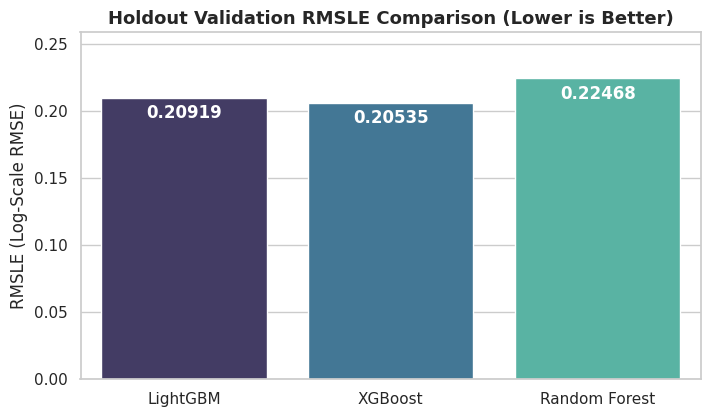

In [22]:
# Model Comparison Visualization
model_names = ['LightGBM', 'XGBoost', 'Random Forest']
val_scores = [score_lgb, score_xgb, score_rf]

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=model_names, y=val_scores, palette='mako')
plt.title("Holdout Validation RMSLE Comparison (Lower is Better)", fontsize=13, fontweight='bold')
plt.ylabel("RMSLE (Log-Scale RMSE)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.5f}", (p.get_x() + 0.22, p.get_height() * 0.93), color='white', fontweight='bold')
plt.ylim(0, max(val_scores) * 1.15)
plt.show()

# `Hyperparameter Tuning`
I optimized the hyperparameters of our leading model (XGBoost) over a defined search space using RandomizedSearchCV with 3-fold cross-validation executed strictly on X_train.

In [23]:
# Hyperparameter Optimization for XGBoost (Best Performing Model):-
param_grid_xgb = {
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators': [1000, 1200, 1500],
    'max_depth': [7, 9, 11],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],    # Feature Subsampling Fraction
    'reg_alpha': [0.0, 0.1, 0.5],     # (L1 Regularization on Leaf Weights)
    'reg_lambda': [0.5, 1.0, 2.0]      # (L2 Regularization on Leaf Weights)
}

xgb_base = xgb.XGBRegressor(
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search strictly on the training split
random_search_xgb.fit(X_train, y_train)

print(f"\n Optimal XGBoost Hyperparameters: {random_search_xgb.best_params_}")
best_xgb = random_search_xgb.best_estimator_

# Validate tuned model on holdout set
val_pred_tuned_xgb = best_xgb.predict(X_valid)
score_tuned_xgb = root_mean_squared_error(y_valid, val_pred_tuned_xgb)
print(f" Tuned XGBoost Validation RMSLE: {score_tuned_xgb:.5f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Optimal XGBoost Hyperparameters: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 1500, 'min_child_weight': 5, 'max_depth': 11, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
 Tuned XGBoost Validation RMSLE: 0.20303


# `Evaluation and Ensembling`
Ensembling combines predictions from diverse model architectures (gradient boosting and bagging), reducing overall prediction variance. We blend the validation predictions using fixed weights: $50\%$ Tuned XGBoost, $40\%$ LightGBM, and $10\%$ Random Forest.

In [24]:
# Weighted Ensembling of Validation Predictions
w_xgb, w_lgb, w_rf = 0.50, 0.40, 0.10

val_ensemble = (w_xgb * val_pred_tuned_xgb) + (w_lgb * val_pred_lgb) + (w_rf * val_pred_rf)
score_ensemble = root_mean_squared_error(y_valid, val_ensemble)
print(f" Final Weighted Ensemble Validation RMSLE: {score_ensemble:.5f}")

 Final Weighted Ensemble Validation RMSLE: 0.20326


# `Test Inference, Target Inversion & Submission Generation`
I generated predictions on X_test from each model, combine them using our ensemble weights, and invert the log transformation:$$\hat{y} = \max(\exp(\hat{z}) - 1, 0)$$via np.expm1(). We save the result to submission.csv and verify its row count and null values.

In [25]:
# Test Inference and Submission Export
# 1. Generate test predictions across models
test_pred_xgb = best_xgb.predict(X_test)
test_pred_lgb = lgb_model.predict(X_test)
test_pred_rf  = rf_model.predict(X_test)

# 2. Blend predictions in log-space
test_pred_log = (w_xgb * test_pred_xgb) + (w_lgb * test_pred_lgb) + (w_rf * test_pred_rf)

# 3. Invert log1p back to actual selling prices ($ USD) and clip at zero
final_prices = np.expm1(test_pred_log)
final_prices = np.clip(final_prices, a_min=0, a_max=None)

# 4. Create and export submission file
submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'TargetValue': final_prices
})

submission.to_csv('submission.csv', index=False)

In [26]:
submission

,TransactionID,TargetValue
0,1139307,64843.340748
1,1139419,80717.509003
2,1139482,28357.659167
3,1139522,20714.937038
4,1139684,11587.246305
...,...,...
14995,6333296,9661.079261
14996,6333344,10283.897677
14997,6333356,11011.050425
14998,6333364,12135.381106


In [27]:
print(f" Null values present in submission: {submission.isnull().any().any()}")

 Null values present in submission: False


# 2'. Duplicates, Missing values, Outliers

## 2.1) Duplicates

In [28]:
'''# Identify duplicates (returns True for duplicate rows)
duplicate_rows = train_df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# Handle duplicates: Drop them completely
train_df = train_df.drop_duplicates()'''

'# Identify duplicates (returns True for duplicate rows)\nduplicate_rows = train_df.duplicated()\nprint(f"Number of duplicate rows: {duplicate_rows.sum()}")\n\n# Handle duplicates: Drop them completely\ntrain_df = train_df.drop_duplicates()'

## 2.2) Missing values

In [29]:
'''from sklearn.impute import SimpleImputer

# Identifying missing values first
print(train_df.isnull().sum())

# Defining strategies for numerical and categorical data
# Numerical strategy
num_imputer = SimpleImputer(strategy='median') 

# Categorical strategy
cat_imputer = SimpleImputer(strategy='most_frequent')

# Applying SimpleImputer to numerical columns
num_cols = train_df.select_dtypes(include=["number"]).columns
train_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])

# Applying SimpleImputer to categorical columns
cat_cols = train_df.select_dtypes(include=["object", "category"]).columns
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])'''

'from sklearn.impute import SimpleImputer\n\n# Identifying missing values first\nprint(train_df.isnull().sum())\n\n# Defining strategies for numerical and categorical data\n# Numerical strategy\nnum_imputer = SimpleImputer(strategy=\'median\') \n\n# Categorical strategy\ncat_imputer = SimpleImputer(strategy=\'most_frequent\')\n\n# Applying SimpleImputer to numerical columns\nnum_cols = train_df.select_dtypes(include=["number"]).columns\ntrain_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])\n\n# Applying SimpleImputer to categorical columns\ncat_cols = train_df.select_dtypes(include=["object", "category"]).columns\ntrain_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])'

## 2.3) Outliers

In [30]:
'''# Identify outliers using IQR
Q1 = train_df[num_cols].quantile(0.25)
Q3 = train_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df[num_cols] < lower_bound) | (train_df[num_cols] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

# Handle outliers: Option A (Remove/Filter out the outliers)
# train_cleaned = train_df[(train_df[num_cols] >= lower_bound) & (train_df[num_cols] <= upper_bound)]

# Handle outliers: Option B (Capping / Winsorization)
train_df[num_cols] = train_df[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)'''

'# Identify outliers using IQR\nQ1 = train_df[num_cols].quantile(0.25)\nQ3 = train_df[num_cols].quantile(0.75)\nIQR = Q3 - Q1\n\nlower_bound = Q1 - 1.5 * IQR\nupper_bound = Q3 + 1.5 * IQR\n\noutliers = train_df[(train_df[num_cols] < lower_bound) | (train_df[num_cols] > upper_bound)]\nprint(f"Number of outliers detected: {len(outliers)}")\n\n# Handle outliers: Option A (Remove/Filter out the outliers)\n# train_cleaned = train_df[(train_df[num_cols] >= lower_bound) & (train_df[num_cols] <= upper_bound)]\n\n# Handle outliers: Option B (Capping / Winsorization)\ntrain_df[num_cols] = train_df[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)'